Write a Python script for Flight Data Analysis:
Problem Statement:
You have a CSV file named 'flight_data.csv' containing flight information such as origin,
destination, and departure time.

Perform the following tasks:


a. Display the summary statistics for departure delays,

b. Calculate the average delay for each airline,

c. Identify the most common departure and arrival destinations,

d. Visualize the distribution of departure delays using a box plot.

In [9]:
import pandas as pd
import io
import numpy as np

# Generate sample flight data
np.random.seed(42) # for reproducibility
num_flights = 100

data = {
    'Flight ID': range(1, num_flights + 1),
    'Airline': np.random.choice(['Airline A', 'Airline B', 'Airline C'], num_flights),
    'Origin': np.random.choice(['JFK', 'LAX', 'ORD', 'DFW', 'ATL'], num_flights),
    'Destination': np.random.choice(['JFK', 'LAX', 'ORD', 'DFW', 'ATL', 'SFO', 'DEN'], num_flights),
    'Scheduled Departure': pd.to_datetime('2023-01-01 08:00:00') + pd.to_timedelta(np.random.randint(0, 365*24*60, num_flights), unit='min'),
    'Departure Delay (minutes)': np.random.normal(loc=15, scale=20, size=num_flights).astype(int),
    'Arrival Delay (minutes)': np.random.normal(loc=10, scale=15, size=num_flights).astype(int)
}

df_flights = pd.DataFrame(data)

# Ensure no negative delays
df_flights['Departure Delay (minutes)'] = df_flights['Departure Delay (minutes)'].apply(lambda x: max(0, x))
df_flights['Arrival Delay (minutes)'] = df_flights['Arrival Delay (minutes)'].apply(lambda x: max(0, x))

# Save to CSV
df_flights.to_csv('flight_data.csv', index=False)

print("flight_data.csv created successfully.")

# Load the CSV into a DataFrame
df_flight = pd.read_csv('flight_data.csv')

display(df_flight.head())

flight_data.csv created successfully.


,Flight ID,Airline,Origin,Destination,Scheduled Departure,Departure Delay (minutes),Arrival Delay (minutes)
0,1,Airline C,DFW,JFK,2023-03-05 00:32:00,0,14
1,2,Airline A,ORD,ORD,2023-01-28 01:07:00,31,7
2,3,Airline C,ORD,SFO,2023-11-30 16:47:00,50,0
3,4,Airline C,JFK,LAX,2023-02-11 05:11:00,1,26
4,5,Airline A,ORD,ATL,2023-03-31 11:51:00,0,7


### Task a: Display the summary statistics for departure delays.

In [10]:
# Summary statistics for 'Departure Delay (minutes)'
display(df_flight['Departure Delay (minutes)'].describe())

,Departure Delay (minutes)
count,100.000000
mean,19.110000
std,17.563101
min,0.000000
25%,2.000000
50%,16.500000
75%,31.250000
max,78.000000


### Task b: Calculate the average delay for each airline.

In [11]:
# Calculate average departure delay for each airline
average_delay_per_airline = df_flight.groupby('Airline')['Departure Delay (minutes)'].mean().reset_index()

display(average_delay_per_airline.sort_values(by='Departure Delay (minutes)', ascending=False))

,Airline,Departure Delay (minutes)
2,Airline C,22.838710
0,Airline A,21.090909
1,Airline B,14.083333


### Task c: Identify the most common departure and arrival destinations.

In [12]:
# Most common departure origins
most_common_origin = df_flight['Origin'].value_counts().reset_index()
most_common_origin.columns = ['Origin', 'Count']
print("Most Common Departure Origins:")
display(most_common_origin.head())

# Most common arrival destinations
most_common_destination = df_flight['Destination'].value_counts().reset_index()
most_common_destination.columns = ['Destination', 'Count']
print("\nMost Common Arrival Destinations:")
display(most_common_destination.head())

Most Common Departure Origins:


,Origin,Count
0,JFK,26
1,ORD,23
2,DFW,21
3,ATL,16
4,LAX,14



Most Common Arrival Destinations:


,Destination,Count
0,ORD,20
1,JFK,18
2,DFW,18
3,SFO,14
4,LAX,12


### Task d: Visualize the distribution of departure delays using a box plot.

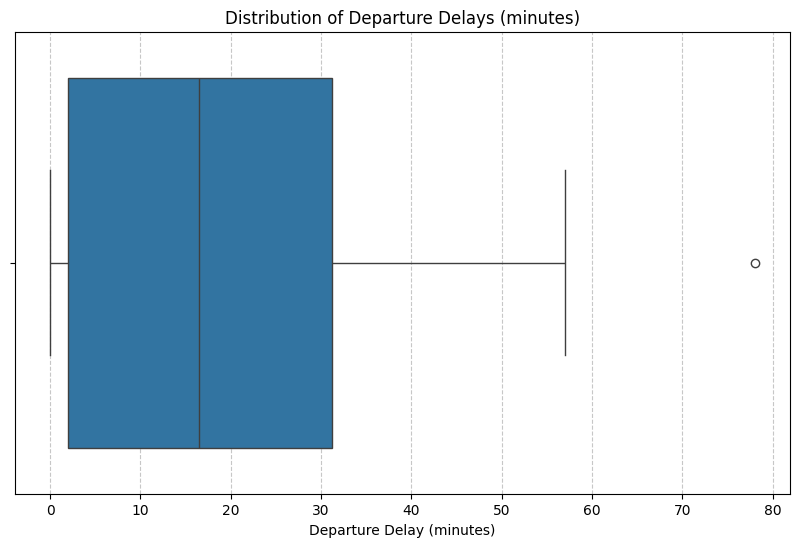

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(x=df_flight['Departure Delay (minutes)'])
plt.title('Distribution of Departure Delays (minutes)')
plt.xlabel('Departure Delay (minutes)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()